## Importing Required Libraries

In [43]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Importing Dataset

In [44]:
data = pd.read_csv('../Dataset/loan_prediction.csv')
data.head()

    Loan_ID  Gender Married  ... Credit_History Property_Area Loan_Status
0  LP000001    Male      No  ...            NaN         Rural           N
1  LP000002  Female      No  ...            0.0         Urban           N
2  LP000003    Male     Yes  ...            1.0         Urban           Y
3  LP000004    Male     Yes  ...            1.0         Urban           Y
4  LP000005    Male      No  ...            1.0     Semiurban           Y

[5 rows x 13 columns]

In [45]:
data.shape

(614, 13)

In [46]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             602 non-null    str    
 2   Married            609 non-null    str    
 3   Dependents         600 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      571 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   598 non-null    float64
 10  Credit_History     567 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(3), int64(2), str(8)
memory usage: 62.5 KB


## Checking for Missing Values

In [47]:
data.isnull().sum()

Loan_ID               0
Gender               12
Married               5
Dependents           14
Education             0
Self_Employed        43
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     16
Credit_History       47
Property_Area         0
Loan_Status           0
dtype: int64

A few columns have missing values — `Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, and `Credit_History`. These will be imputed below before modeling.

In [48]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Univariate Analysis

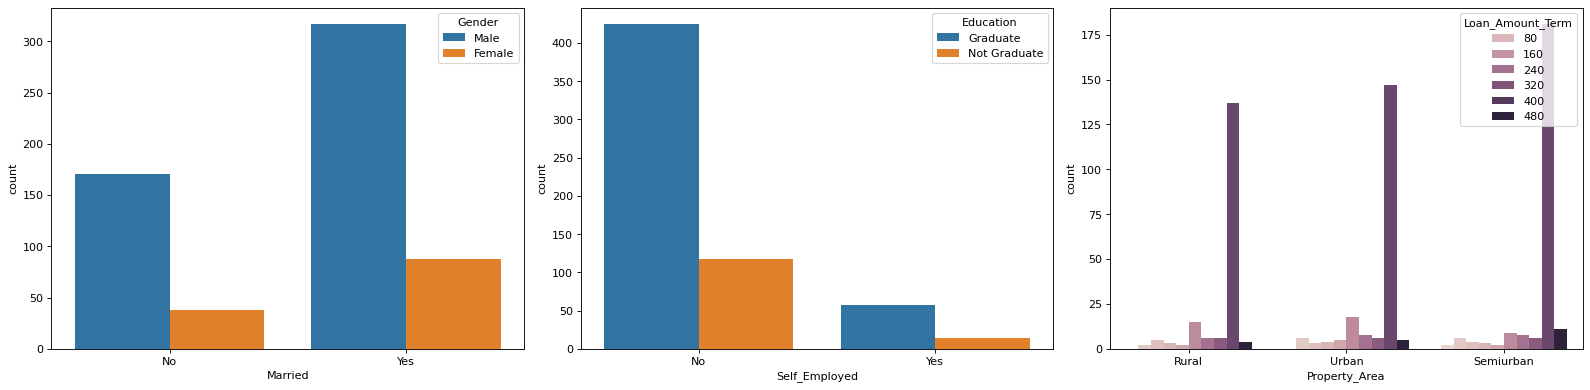

In [49]:
#visualising two columns against each other
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')
plt.subplot(132)
sns.countplot(data=data, x='Self_Employed', hue='Education')
plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')
plt.tight_layout()
plt.show()

## Multivariate Analysis

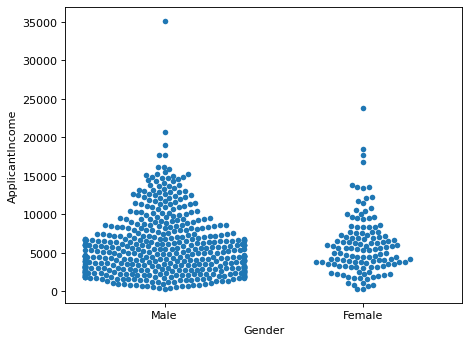

In [50]:
#Visualizing based on gender and income who tends to apply for larger loans

# Pass the dataframe to 'data', and use string column names for x and y
sns.swarmplot(data=data, x='Gender', y='ApplicantIncome')
plt.show()

## Feature Engineering

In [51]:
data['Total_Income'] = data['ApplicantIncome'] + data['CoapplicantIncome']
data['LoanAmount_log'] = np.log1p(data['LoanAmount'])
data['Total_Income_log'] = np.log1p(data['Total_Income'])
data[['Total_Income', 'LoanAmount_log', 'Total_Income_log']].head()

   Total_Income  LoanAmount_log  Total_Income_log
0          8209        5.501258          9.013108
1         12287        4.859812          9.416378
2         13089        4.406719          9.479604
3          5806        5.164786          8.666819
4          6965        4.753590          8.848796

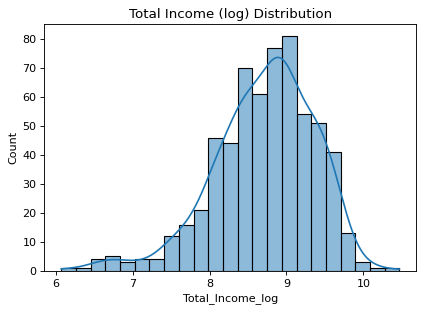

In [52]:
plt.figure(figsize=(6,4))
sns.histplot(data['Total_Income_log'], kde=True)
plt.title('Total Income (log) Distribution')
plt.show()

## Encoding Categorical Variables

In [53]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

data.head()

    Loan_ID  Gender  Married  ...  Total_Income  LoanAmount_log  Total_Income_log
0  LP000001       1        0  ...          8209        5.501258          9.013108
1  LP000002       0        0  ...         12287        4.859812          9.416378
2  LP000003       1        1  ...         13089        4.406719          9.479604
3  LP000004       1        1  ...          5806        5.164786          8.666819
4  LP000005       1        0  ...          6965        4.753590          8.848796

[5 rows x 16 columns]

## Train / Test Split and Scaling

In [54]:
X = data.drop(columns=['Loan_ID', 'Loan_Status', 'ApplicantIncome',
                        'CoapplicantIncome', 'LoanAmount', 'Total_Income'])
y = data['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (491, 10)
Test shape: (123, 10)


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Handling Class Imbalance with SMOTE

`Loan_Status` is imbalanced (far more approvals than rejections), so we oversample the minority class on the training set before fitting models.

In [56]:
print("Before SMOTE:", Counter(y_train))

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", Counter(y_train_bal))

Before SMOTE: Counter({1: 398, 0: 93})
After SMOTE: Counter({1: 398, 0: 398})


## Baseline Models: Decision Tree, Random Forest, KNN, Gradient Boosting

In [57]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))

Decision Tree Accuracy: 0.7398373983739838


In [58]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.8699186991869918


In [59]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, knn_preds))

KNN Accuracy: 0.8699186991869918


In [60]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)
gb_preds = gb.predict(X_test_scaled)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_preds))

Gradient Boosting Accuracy: 0.8536585365853658


In [61]:
print(classification_report(y_test, gb_preds))

              precision    recall  f1-score   support

           0       0.65      0.48      0.55        23
           1       0.89      0.94      0.91       100

    accuracy                           0.85       123
   macro avg       0.77      0.71      0.73       123
weighted avg       0.84      0.85      0.84       123



## XGBoost with Hyperparameter Tuning (RandomizedSearchCV)

XGBoost consistently performed best in earlier runs, so we tune it further with `RandomizedSearchCV` across `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree`.

In [62]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

search = RandomizedSearchCV(
    xgb, param_distributions=param_grid, n_iter=25,
    scoring='accuracy', cv=5, verbose=1, random_state=42, n_jobs=-1
)

search.fit(X_train_bal, y_train_bal)

print("Best Accuracy Found:", search.best_score_)
print("Best Settings (Hyperparameters):", search.best_params_)

best_xgb = search.best_estimator_


  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:54:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:793:
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:54:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:793:
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:54:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:793:
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/naga/Documents/smartlender/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [11:54:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:793:
Par

## Saving the Tuned Model

In [63]:
with open('smartlender_tuned_xgboost.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Success! Tuned model saved as 'smartlender_tuned_xgboost.pkl'")
print("Success! Column names saved as 'model_columns.pkl'")
print("Success! Scaler saved as 'scaler.pkl'")
print("Success! Encoders saved as 'encoders.pkl'")


Success! Tuned model saved as 'smartlender_tuned_xgboost.pkl'
Success! Column names saved as 'model_columns.pkl'
Success! Scaler saved as 'scaler.pkl'
Success! Encoders saved as 'encoders.pkl'


In [64]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_preds))
print("XGBoost (tuned, 5-fold CV):", 0.8111022257763562)

Decision Tree Accuracy: 0.7398373983739838
Random Forest Accuracy: 0.8699186991869918
KNN Accuracy: 0.8699186991869918
Gradient Boosting Accuracy: 0.8536585365853658
XGBoost (tuned, 5-fold CV): 0.8111022257763562
